RGB


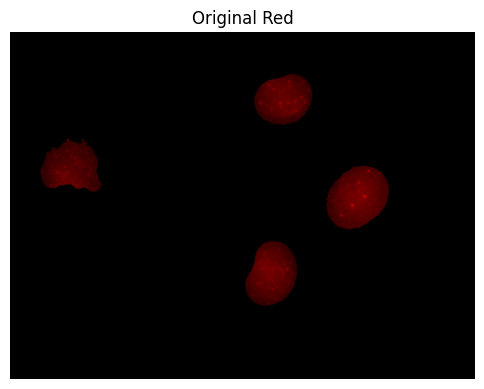

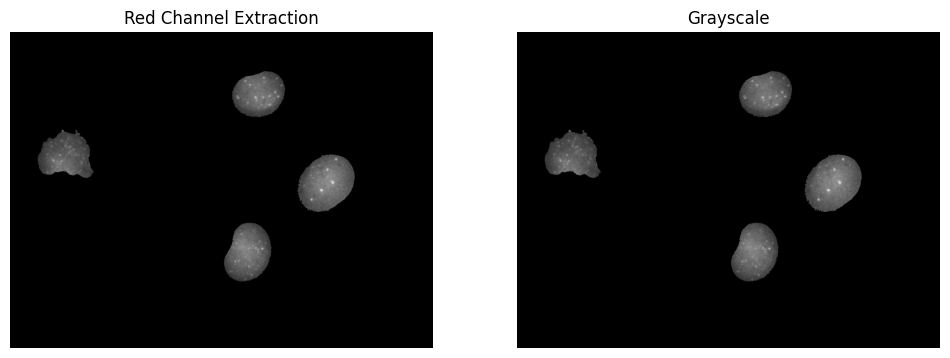

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import pd
from PIL import Image

img_path = "output/masks/Li_masked.png"
img = Image.open(img_path).convert("RGB") #Force image into 3 channels (should already be the case)
img_np = np.array(img)

# Color image
plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.title("Original Red")
plt.axis('off')

mode = img.mode
print(mode)

# Convert to grayscale
gray = np.array(img.convert("L"))

# Plot true gray and red channel extraction side by side
plt.figure(figsize=(12,6))

#This creates an image that reflects how much red is in the
#original image (may look gray, but represents pure red data).
red_channel = img_np[:, :, 0] # is the numerical intensity map of the red channel

plt.subplot(1,2,1)
plt.imshow(red_channel, cmap='gray')
plt.title("Red Channel Extraction")
plt.axis('off')

# Grayscale image
plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

plt.show()

On top is the original image and in the second row we see the red channel extraction in comparison to the grayscale.
The next step is to compare the intensities of the images. Later we will run the foci detection algorithm on both versions to see if the varying intensities has influence on the detection accuracy.

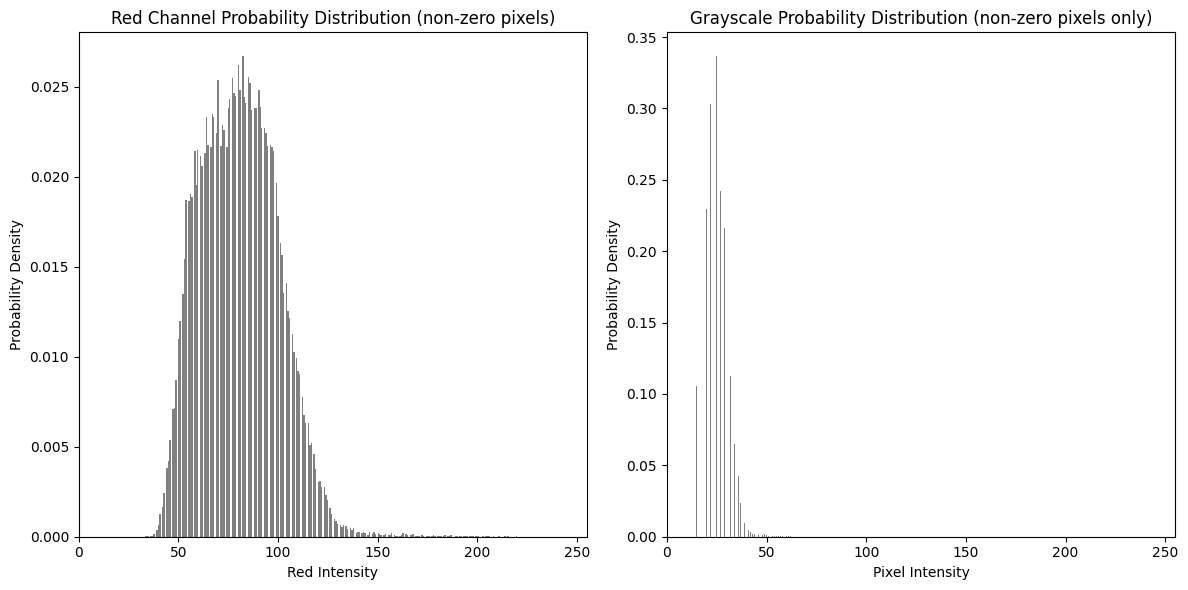

In [127]:
import matplotlib.pyplot as plt

red_nonzero = red_channel[red_channel > 0]
gray_nonzero = gray[gray > 0]

#Plotting the normalized intensity histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
#density=True to normalize the Y-axis
plt.hist(red_nonzero, bins=256, color='grey', density=True)
plt.title("Red Channel Probability Distribution (non-zero pixels)")
plt.xlabel("Red Intensity")
plt.ylabel("Probability Density")
plt.xlim(0, 255)

plt.subplot(1, 2, 2)
plt.hist(gray_nonzero, bins=256, color='gray', density=True)
plt.title("Grayscale Probability Distribution (non-zero pixels only)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Probability Density")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()

The difference in the Y-axis labels reflects the different data sources and data processing that created the two histograms:
__Red Channel Extraction Intensity (plt.hist(red_nonzero, ...)):__
- This histogram is plotting the raw numerical values extracted directly from one specific color channel (Red).
The values represent the intensity of the Red light only, often referred to simply as Red Intensity.

__Grayscale Pixel Intensity (plt.hist(gray_nonzero, ...)):__
- The data for this histogram was created by calling img.convert("L"). This is a process that mathematically combines the Red, Green, and Blue channels to determine the overall perceived brightness or Luminance of each pixel.

## Count Cells in Image and annotate

Found 4 cells.


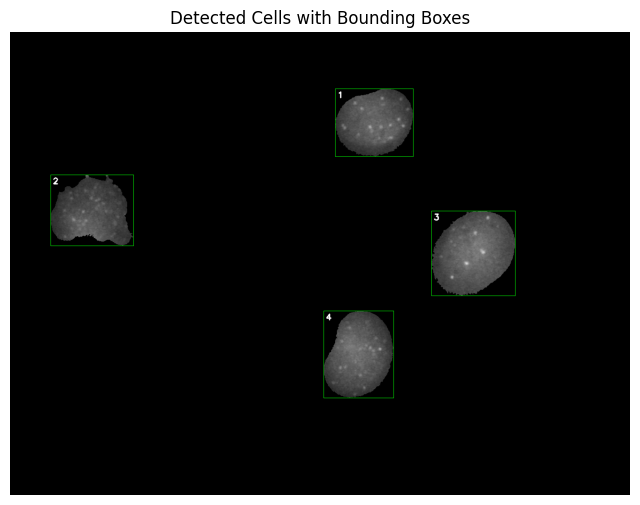

In [133]:
import cv2
from skimage import io, measure


intensity_image = red_channel
#intensity_image = gray


'''if image.ndim == 3:
    intensity_image = image[:, :, 0] # Red channel
else:
    intensity_image = image'''

# 2. Find Cells (Segmentation)
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells)

print(f"Found {len(regions)} cells.")

# Preparation for Annotation
# Convert the single-channel intensity image to a 3-channel image for drawing to allow colored annotation
output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)

#Annotation Loop
for i, region in enumerate(regions):
    # Skip tiny noise
    if region.area < 50:
        continue

    # 1. Get coordinates of the cell
    minr, minc, maxr, maxc = region.bbox

    # Draw Bounding Box
    # The order is (column, row) for the top-left and bottom-right corners
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    # Add Label (Cell ID - White)
    label_text = str(region.label)
    # Label is placed slightly inside the top-left corner
    cv2.putText(output_image, label_text, (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

#Display Result
plt.figure(figsize=(8, 8))
# OpenCV uses BGR internally, so we convert it to RGB for Matplotlib
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells with Bounding Boxes")
plt.axis("off")
plt.show()


In [134]:
import numpy as np
import cv2
from skimage import io, measure, feature # Added feature for peak detection
import matplotlib.pyplot as plt


# 2. Find Cells (Segmentation)
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, intensity_image=intensity_image) # Pass intensity_image for region properties

print(f"Found {len(regions)} cells.")

# --- Preparation for Annotation & Dataframe ---
output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

# --- Annotation and Foci Detection Loop ---
for region in regions:
    # Skip tiny noise
    if region.area < 50:
        continue

    # 1. Get coordinates of the cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    # Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    # Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # 2. Extract the local intensity data for the current cell region
    # We use the bounding box to crop the original intensity map
    cropped_intensity = intensity_image[minr:maxr, minc:maxc]

    # 3. Detect Peaks (Foci) within the cropped region
    # Set a detection threshold relative to the overall max intensity of the image (or customize)
    peak_coords_local = feature.peak_local_max(
        cropped_intensity,
        min_distance=5,  # Minimum pixel distance between peaks
        threshold_abs=np.percentile(intensity_image, 99) * 0.4 # Tune this threshold
    )

    # 4. Annotate and Record Foci
    for local_r, local_c in peak_coords_local:
        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        #Annotation: Foci Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: Circle around Foci
        # The radius of the circle is an estimate (e.g., min_distance/2)
        #radius = 5 # Use a fixed radius for visualization
        cv2.circle(output_image, (global_c, global_r), radius, (0, 255, 0), 1)

        # --- Data Collection ---
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity": intensity_image[global_r, global_c],
            "cell_area": region.area
        })
        peak_id_counter += 1

# Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_analysis.csv"
df.to_csv(csv_path, index=False)

# --- Display Result ---
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Foci (Total Foci: {len(foci_records)})")
plt.axis("off")
plt.show()

print(f"\nFoci data saved to {csv_path}")

Found 4 cells.


error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'circle'
> Overload resolution failed:
>  - Argument 'radius' is required to be an integer
>  - Argument 'radius' is required to be an integer


Total Cells: 4
Total Foci: 236
   cell_id  peak_id  global_x  global_y  intensity_mean  intensity_peak  \
0        1        1       882       212          119.93             157   
1        1        2       808       214          149.02             181   

   foci_radius_pixels  foci_area_approx  cell_area image_id  
0                3.77             44.68      20229           
1                3.77             44.68      20229           


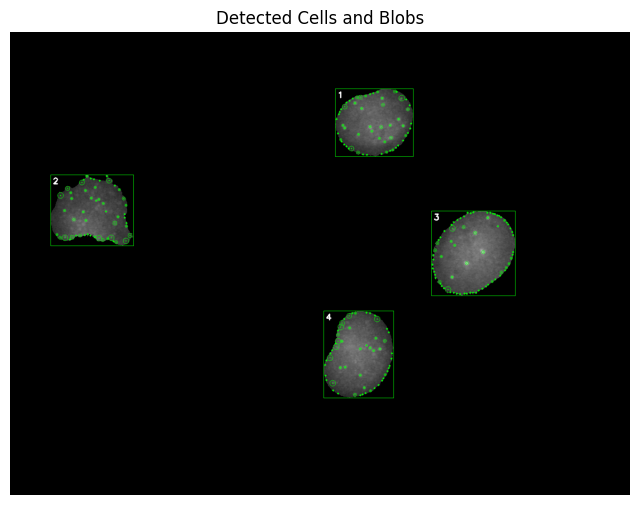

In [147]:
import numpy as np
import cv2
import pandas as pd
from skimage import io, measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk

#Find Cells
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, intensity_image=intensity_image)

output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

#Annotation and Foci Detection Loop
for region in regions:
    #Skip tiny noise
    if region.area < 50:
        continue

    #Get cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    #Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    #Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    #Extract the local intensity data for the current cell region
    cropped_intensity = intensity_image[minr:maxr, minc:maxc]

    #Blob Detection --- Laplacian of Gaussian
    #Find bright blobs and estimate their size (sigma)
    #The returned array is [row, column, sigma]
    blobs_log = feature.blob_log(
        cropped_intensity,
        min_sigma=2,    #Smallest expected focus size (size in pixels)
        max_sigma=5,   #Largest expected focus size
        num_sigma=10,
        threshold=0.05   #Lower threshold detects fainter foci; between 0 and 1
    )

    #Convert sigma to radius (radius = sigma * sqrt(2))
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    #Annotate and Record Foci
    for local_r, local_c, radius in blobs_log:
        local_r, local_c = int(local_r), int(local_c)

        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        # Check if the blob center is actually inside the segmented cell mask
        if labeled_cells[global_r, global_c] != region.label:
            continue

        #Annotation: Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: estimated radius
        cv2.circle(output_image, (global_c, global_r), int(radius), (0, 255, 0), 1)

        #Use the calculated radius to define the focus area
        focus_radius = int(round(radius))

        #Create coordinates for the focus disk centered at (global_r, global_c)
        rr, cc = disk((global_r, global_c), focus_radius, shape=intensity_image.shape)

        #Extract the intensities from the image that fall within the disk coordinates
        focus_intensities = intensity_image[rr, cc]

        #Calculate the mean intensity over the focus area
        intensity_mean = np.mean(focus_intensities)

        #Data Collection
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity_mean": round(intensity_mean, 2),
            "intensity_peak": intensity_image[global_r, global_c],
            "foci_radius_pixels": round(radius, 2),
            "foci_area_approx": round(np.pi * (radius**2), 2),
            "cell_area": round(region.area),
            "image_id":""  #Empty for now; wo only analyze one image ToDo: find way to extract name from folder for each image
        })
        peak_id_counter += 1

#Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_log_analysis.csv"
df.to_csv(csv_path, index=False)

print(f"Total Cells: {len(regions)}")
print(f"Total Foci: {len(foci_records)}")
print(df.head(2))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Blobs")
plt.axis("off")
plt.show()

Found 4 cells. Showing first 10...


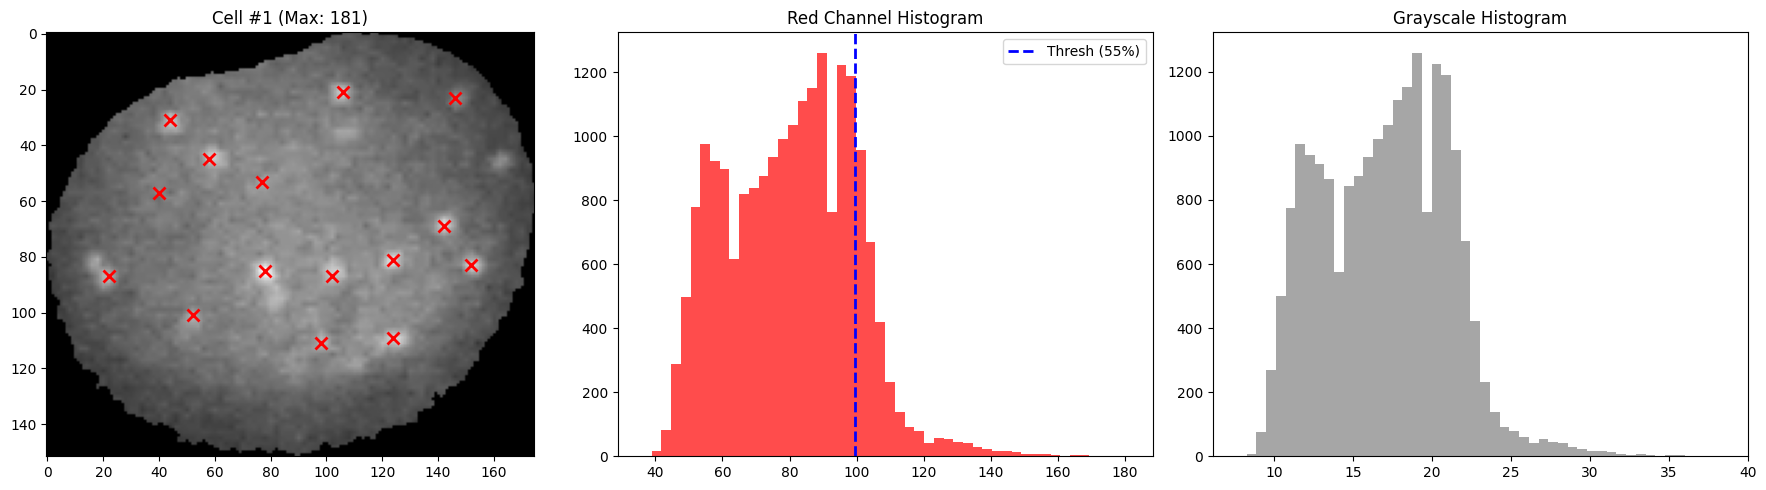

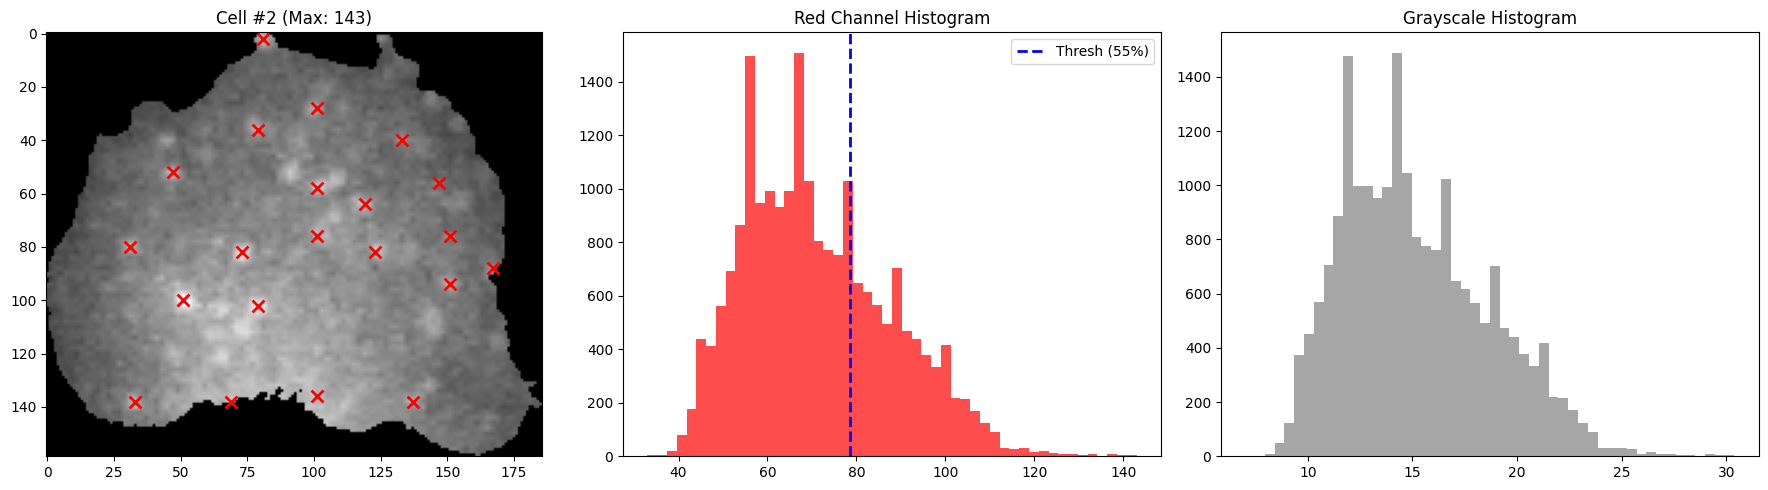

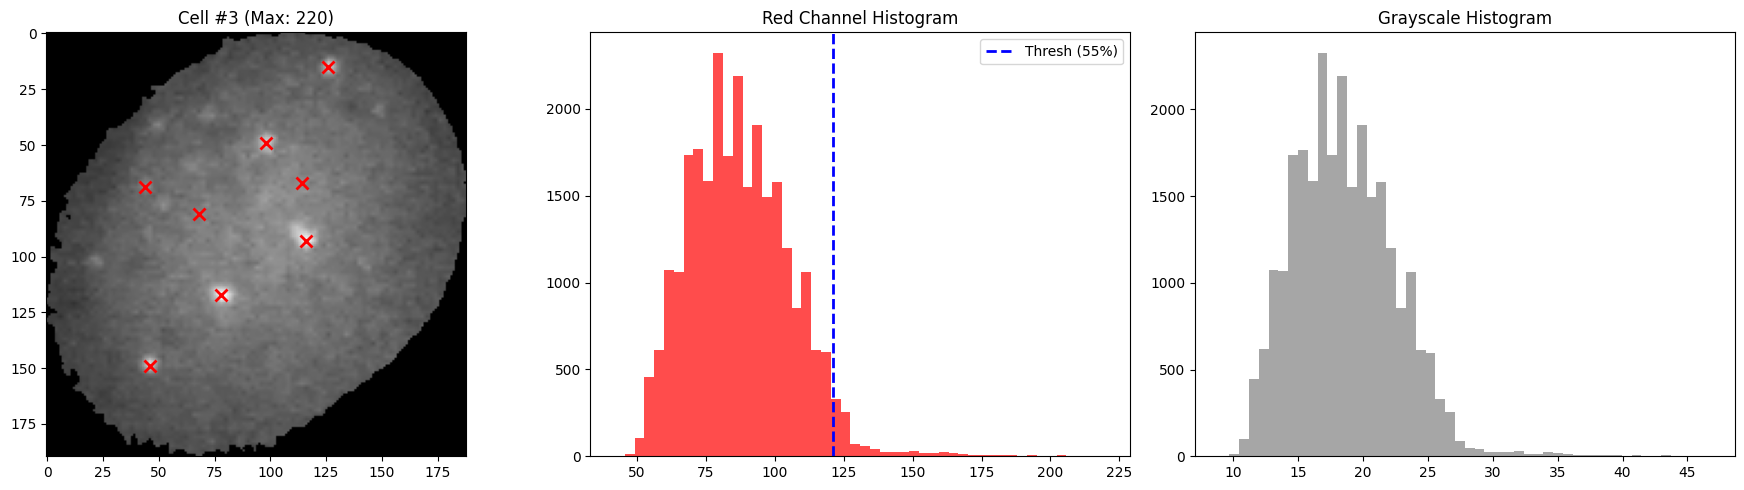

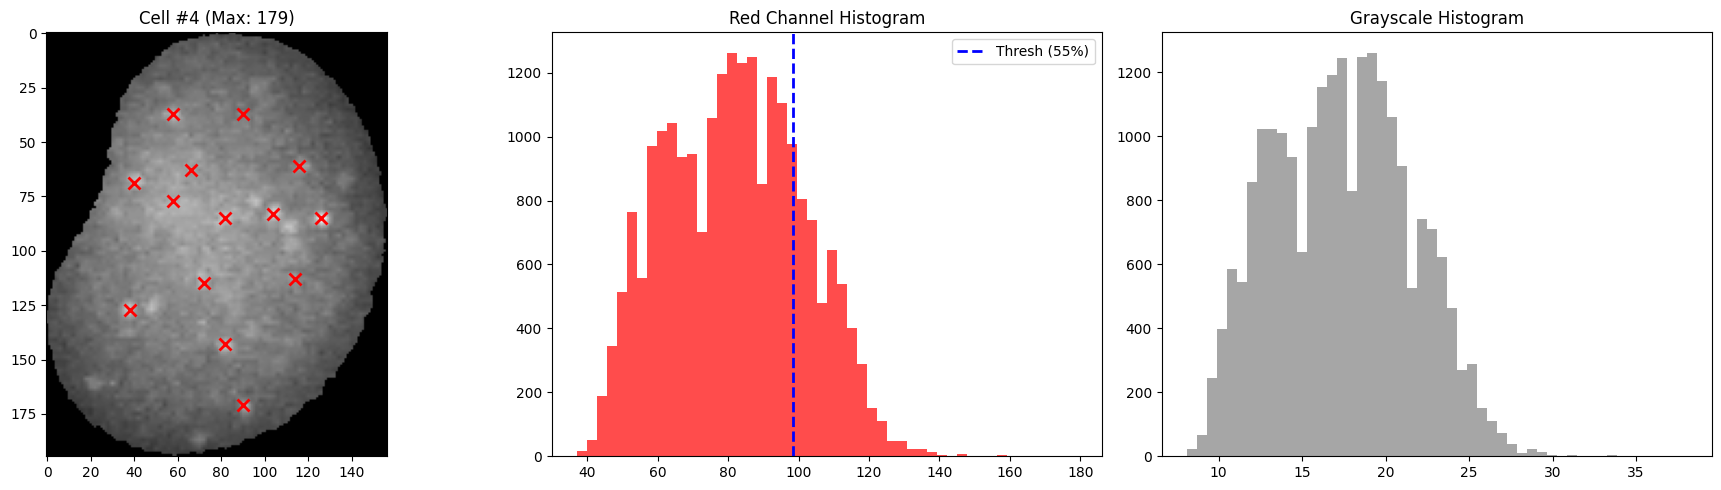

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, measure, feature, color

def analyze_cells_relative_threshold(image_path, relative_threshold, min_distance, max_cells=10):

    # --- 1. Load & Prepare Images ---
    # Load original
    image = io.imread(image_path)

    # Handle RGB vs Grayscale
    if image.ndim == 2:
        img_rgb = color.gray2rgb(image)
        img_red = image
    elif image.shape[2] == 4: # RGBA
        img_rgb = image[:, :, :3]
        img_red = image[:, :, 0]
    else: # RGB
        img_rgb = image
        img_red = image[:, :, 0]

    # Pre-calculate Grayscale for comparison
    img_gray = color.rgb2gray(img_rgb)
    # Scale grayscale to 0-255 if needed for fair histogram comparison
    if img_gray.max() <= 1.0 and img_red.max() > 1.0:
        img_gray = img_gray * 255

    # --- 2. Find Cells ---
    # Threshold > 0 to find cell shapes
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found {len(regions)} cells. Showing first {max_cells}...")

    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop 1: Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # Crop 2: Grayscale (The Comparison)
        crop_gray = img_gray[minr:maxr, minc:maxc].copy()
        crop_gray[~region.image] = 0

        # --- B. Find Peaks (Relative Threshold) ---
        # 1. Find max intensity in THIS cell
        cell_max = crop_red.max()

        # 2. Calculate the specific cutoff for THIS cell
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        # 3. Detect
        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold, # We calculated this dynamically above
            exclude_border=False
        )

        # --- C. Visualization ---
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))

        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='gray')
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'rx', markersize=8, markeredgewidth=2)

        # Plot 2: Red Histogram
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2, label=f'Thresh ({relative_threshold*100:.0f}%)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].legend()

        # Plot 3: Grayscale Histogram
        ax[2].hist(crop_gray[region.image], bins=50, color='gray', alpha=0.7)
        ax[2].set_title("Grayscale Histogram")

        plt.tight_layout()
        plt.show()


# Change 'relative_threshold' to tune sensitivity (0.6 = 60% of max brightness)
analyze_cells_relative_threshold(
    "output/masks/Li_masked.png",
    relative_threshold=0.55,
    min_distance=12
)

Found Cells: 4


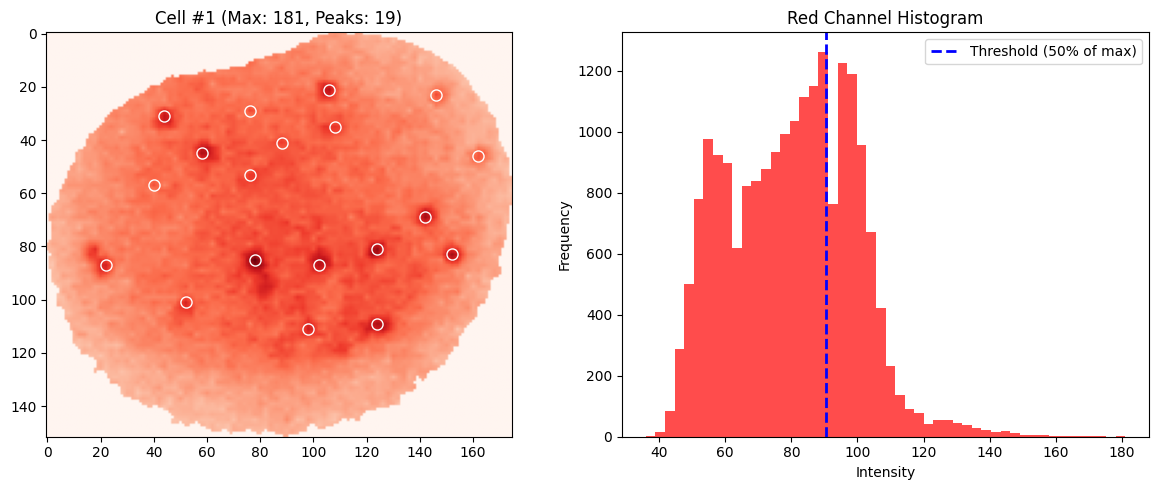

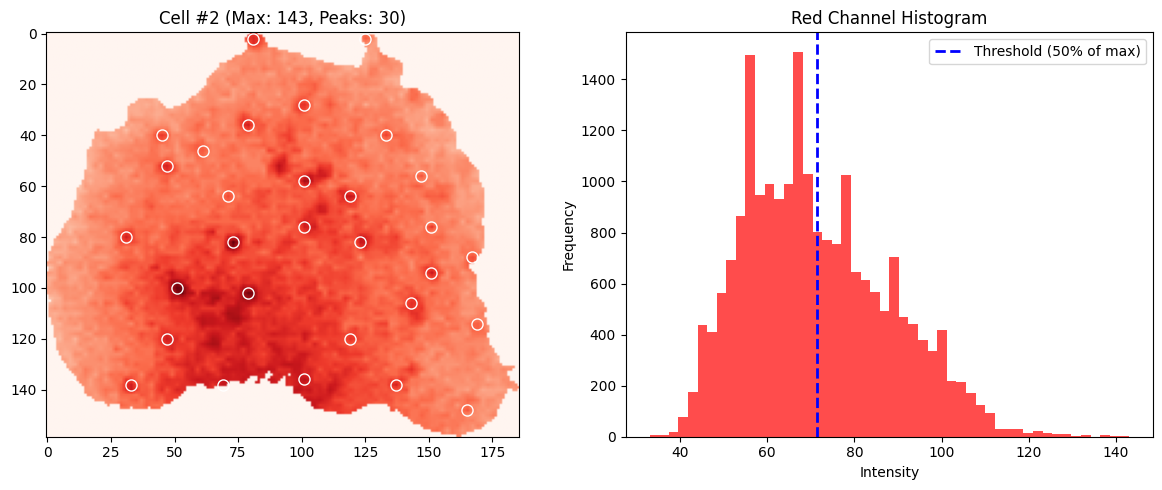

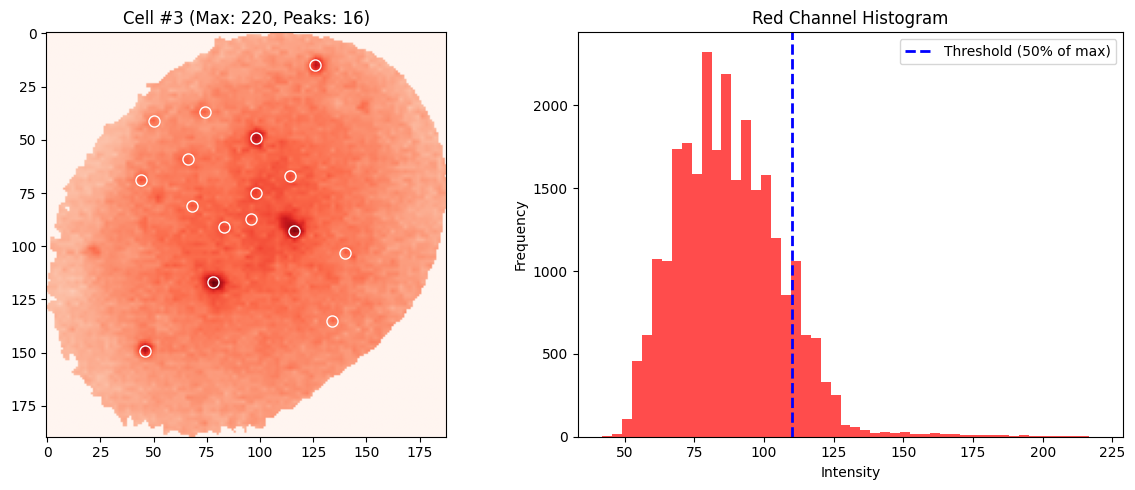

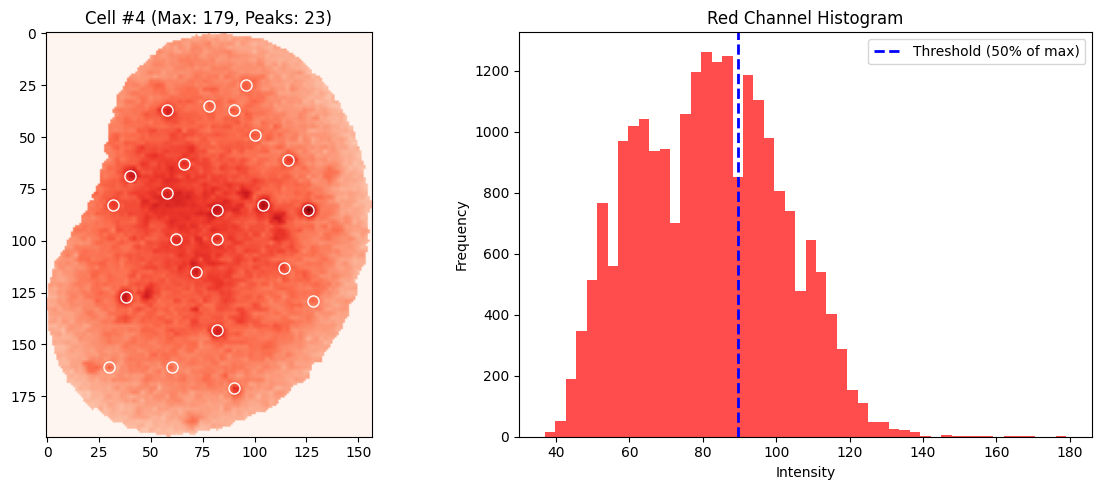

In [153]:
import os

def analyze_cells_relative_threshold(relative_threshold, min_distance, max_cells=10):

    #use image that is not gray
    img_red = red_channel

    # --- 2. Find Cells ---
    # Threshold > 0 to find cell shapes
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found Cells: {len(regions)}")

    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # Note: Grayscale related code removed from here.

        # --- B. Find Peaks (Relative Threshold) ---
        # 1. Find max intensity in THIS cell
        cell_max = crop_red.max()

        # 2. Calculate the specific cutoff for THIS cell
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        # 3. Detect
        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold, # Dynamic threshold
            exclude_border=False
        )

        # --- C. Visualization ---
        # Reduced subplots from 3 to 2
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='Reds') # Use 'Reds' for color consistency
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max}, Peaks: {len(local_peaks)})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'wo',
                   markerfacecolor='none', markeredgecolor='white',
                   markersize=8, markeredgewidth=1)

        # Plot 2: Red Histogram (Now uses the second subplot slot)
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2,
                      label=f'Threshold ({relative_threshold*100:.0f}% of max)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].set_xlabel("Intensity")
        ax[1].set_ylabel("Frequency")
        ax[1].legend()

        # Removed Plot 3 (Grayscale Histogram)

        plt.tight_layout()
        plt.show()


# Change 'relative_threshold' to tune sensitivity (0.55 = 55% of cell's max brightness)
analyze_cells_relative_threshold(
    relative_threshold=0.50,
    min_distance=10
)

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage import io, measure, feature
from skimage.draw import disk
import cv2 # Required for drawing utilities



def analyze_cells_relative_threshold(relative_threshold, min_distance, max_cells=10):

    # Use image that is not gray

    img_red = red_channel

    # --- 1. Initialize Full Annotation Canvas ---
    # Convert single-channel red data to a 3-channel image for colored annotations (BGR order)
    zeros = np.zeros_like(img_red)
    full_output_canvas = cv2.merge([zeros, zeros, img_red]) # Creates a red-colored image

    # --- 2. Find Cells ---
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    # Using img_red for regionprops to get intensity data
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found Cells: {len(regions)}")

    foci_records = []
    peak_id_counter = 1
    image_filename = os.path.basename(image_path)
    image_id_value = os.path.splitext(image_filename)[0]


    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # --- Draw Annotations on FULL IMAGE CANVAS (NEW) ---
        # 1. Draw Bounding Box (Green)
        cv2.rectangle(full_output_canvas, (minc, minr), (maxc, maxr), (0, 255, 0), 1)
        # 2. Add Cell Label (White)
        cv2.putText(full_output_canvas, str(region.label), (minc + 5, minr + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        # ----------------------------------------------------


        # --- B. Find Peaks (Relative Threshold - using peak_local_max) ---
        cell_max = crop_red.max()
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold,
            exclude_border=False
        )

        # --- C. Data Collection & Foci Annotation on FULL IMAGE CANVAS ---
        for local_r, local_c in local_peaks:

            # Convert local coordinates back to global image coordinates
            global_r = int(minr + local_r)
            global_c = int(minc + local_c)

            # --- Foci Annotation on FULL IMAGE (NEW) ---
            # Draw tiny white dot at the center of the peak
            cv2.circle(full_output_canvas, (global_c, global_r), 2, (255, 255, 255), -1)

            # --- Data Collection (Requires integration with former LoG code for size metrics) ---
            # NOTE: Since you removed LoG, size metrics (radius/area) are undefined here.
            # We'll use placeholder or only include defined metrics.

            foci_records.append({
                "cell_id": region.label,
                "peak_id": peak_id_counter,
                "global_x": global_c,
                "global_y": global_r,
                "intensity_peak": img_red[global_r, global_c],
                "foci_radius_pixels": 0.0, # Placeholder/Undefined without Blob LoG
                "cell_area": round(region.area),
                "image_id": image_id_value
            })
            peak_id_counter += 1

        # --- D. Visualization of Single Cell and Histogram ---
        # (This remains the same as your original request for side-by-side view)
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='Reds')
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max}, Peaks: {len(local_peaks)})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'wo',
                   markerfacecolor='none', markeredgecolor='white',
                   markersize=8, markeredgewidth=1)

        # Plot 2: Red Histogram
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2,
                      label=f'Threshold ({relative_threshold*100:.0f}% of max)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].set_xlabel("Intensity")
        ax[1].set_ylabel("Frequency")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

    # --- FINAL DISPLAY OF FULL ANNOTATED IMAGE (NEW) ---
    plt.figure(figsize=(10, 10))
    # Convert BGR canvas to RGB for correct Matplotlib display
    plt.imshow(cv2.cvtColor(full_output_canvas, cv2.COLOR_BGR2RGB))
    plt.title("Full Image Annotation: All Cells and Detected Foci")
    plt.axis('off')
    plt.show()

    # --- CSV Saving ---
    df = pd.DataFrame(foci_records)
    csv_path = f"output/{image_id_value}_foci_analysis.csv"
    os.makedirs(os.path.dirname(csv_path) or '.', exist_ok=True)
    df.to_csv(csv_path, index=False)

    print(f"\n--- Analysis Complete ---")
    print(f"Total Foci Detected: {len(foci_records)}")
    print(f"Data saved to: {csv_path}")
    print("\nFirst 5 rows of the generated DataFrame:")
    print(df.head(5))


# --- EXECUTION ---
analyze_cells_relative_threshold(
    relative_threshold=0.53,
    min_distance=12
)

Found Cells: 4


NameError: name 'image_path' is not defined